# **Part1: I. GENERARE poezii: varianta ROGPT2, modificari ale poeziei generate**

1. Transform data setul din format csv in formatul txt acceptat de  RoGPT2-medium

In [ ]:
import pandas as pd

# Citește datasetul
df = pd.read_csv("dataset_generate.csv", encoding="utf-8")

# Pregătim fișierul TXT corect pentru fine-tuning
with open("train_dataset.txt", "w", encoding="utf-8") as f:
    for _, row in df.iterrows():
        autor = row['autor'].strip()
        titlu = row['titlu'].strip()
        text = row['text'].strip()

        # Scriem în format clar:
        f.write(f"<|autor={autor}|>\n")
        f.write(f"<|titlu={titlu}|>\n")
        f.write(f"<|poezie={text}|>\n")
        f.write(f"<|endofpoem|>\n\n")


2. SETUP Fine-Tuning RoGPT2 : antrenare model pe 5 epoci


In [ ]:
# 1. Instalează Transformers
!pip install transformers

# 2. Librării necesare
import os
from transformers import AutoTokenizer, AutoModelForCausalLM, Trainer, TrainingArguments, TextDataset, DataCollatorForLanguageModeling
from google.colab import files

# 3. Setări
MODEL_NAME = "readerbench/RoGPT2-medium"
OUTPUT_DIR = "/content/poetgpt5"  # Nume nou pentru modelul tău
TRAIN_FILE = "train_dataset.txt"

# 4. Creează folder dacă nu există
os.makedirs(OUTPUT_DIR, exist_ok=True)

# 5. Încarcă modelul și tokenizer-ul
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForCausalLM.from_pretrained(MODEL_NAME)

# 6. Tokeni speciali
special_tokens = {'additional_special_tokens': ['<|autor|>', '<|titlu|>', '<|poezie|>', '<|endofpoem|>']}
tokenizer.add_special_tokens(special_tokens)
model.resize_token_embeddings(len(tokenizer))

# 7. Tokenul de padding
tokenizer.pad_token = tokenizer.eos_token

# 8. Dataset
dataset = TextDataset(
    tokenizer=tokenizer,
    file_path=TRAIN_FILE,
    block_size=128
)

data_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer,
    mlm=False
)

# 9. Argumente de antrenare
training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    overwrite_output_dir=True,
    num_train_epochs=5,
    per_device_train_batch_size=2,
    save_steps=500,
    save_total_limit=2,
    logging_steps=100,
    prediction_loss_only=True,
    fp16=True,
)

# 10. Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    data_collator=data_collator,
    train_dataset=dataset,
)

# 11. Antrenare
trainer.train()

# 12. Salvare model
model.save_pretrained(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)

print("✅ Model salvat local!")



/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/563 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/869 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/985k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/542k [00:00<?, ?B/s]

...

 ··········


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: emilia-iliana (emilia-iliana-university-politehnica-of-bucharest) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


`loss_type=None` was set in the config but it is unrecognised.Using the default loss: `ForCausalLMLoss`.


Step,Training Loss
100,4.311300
200,3.653500
300,3.531500
400,3.483700
500,3.444800
600,3.358800
700,3.444400
800,3.400800
900,3.327900
1000,3.412900


✅ Model salvat local!


SALVARE MODEL LOCAL!!!!! de facut la finalul executiei!!!


In [ ]:
import shutil

# Creează fișier ZIP din folderul în care ai salvat modelul
shutil.make_archive("poetgpt5", 'zip', "/content/poetgpt5")
from google.colab import files
files.download("poetgpt5.zip")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
!cp poetgpt5.zip /content/drive/MyDrive/ACS-CTI/LICENTA/modele/



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Part 1: II. poezii generate/perfomanta/modificare prompturi

Modificare curatare prompturi si poezii geenerate dupa endofpoem

In [ ]:
import re
from transformers import pipeline, AutoTokenizer, AutoModelForCausalLM


# 1. Setăm path-ul local către modelul salvat
MODEL_PATH = "/content/poet_gpt5"  # sau alt path local

# 2. Încărcăm tokenizerul și modelul din path-ul local
tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH, local_files_only=True)
model = AutoModelForCausalLM.from_pretrained(MODEL_PATH, local_files_only=True)

# 3. Ne asigurăm că EOS token este <|endofpoem|>
if tokenizer.eos_token != "<|endofpoem|>":
    tokenizer.eos_token = "<|endofpoem|>"

# 4. Construim pipeline-ul de generare
generator = pipeline(
    "text-generation",
    model=model,
    tokenizer=tokenizer,
)

# 5. Funcție robustă care returnează doar poezia curată
def genereaza_poezie_curata(generator, autor, titlu, max_cuvinte=100, max_length=512):
    prompt = f"<|autor={autor}|>\n<|titlu={titlu}|>\n<|poezie=>"

    output = generator(
        prompt,
        max_length=max_length,
        do_sample=True,
        temperature=0.7,
        top_k=50,
        top_p=0.9,
        repetition_penalty=1.1,
        num_return_sequences=1,
        eos_token_id=tokenizer.convert_tokens_to_ids("<|endofpoem|>")
    )

    # Textul generat brut
    text_generat = output[0]["generated_text"]

    # Extragem doar poezia dintre <|poezie=> și <|endofpoem|>
    try:
        start = text_generat.index("<|poezie=>") + len("<|poezie=>")
        end = text_generat.index("<|endofpoem|>", start)
        poezie_raw = text_generat[start:end].strip()
    except ValueError:
        # fallback dacă lipsesc markerii
        poezie_raw = text_generat.split("<|poezie=>")[-1].strip()

    # Ștergem orice token special rămas în text (<|...|>)
    poezie_curata = re.sub(r"<\|.*?\|>", "", poezie_raw).strip()

    # Limităm numărul de cuvinte dacă e cazul
    cuvinte = poezie_curata.split()
    if len(cuvinte) > max_cuvinte:
        poezie_curata = " ".join(cuvinte[:max_cuvinte])

    return poezie_curata


HFValidationError: Repo id must be in the form 'repo_name' or 'namespace/repo_name': '/content/poet_gpt5'. Use `repo_type` argument if needed.

I. Generare poezii:

In [ ]:
from transformers import pipeline, AutoTokenizer, AutoModelForCausalLM

# 1. Setăm calea către modelul salvat
MODEL_PATH = "/content/poet_gpt5"

# 2. Încarcăm modelul și tokenizerul O SINGURĂ DATĂ
tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)
model = AutoModelForCausalLM.from_pretrained(MODEL_PATH)

# Setăm tokenul de endofpoem dacă nu e corect
if tokenizer.eos_token != "<|endofpoem|>":
    tokenizer.eos_token = "<|endofpoem|>"

# 3. Creăm pipeline-ul
generator = pipeline(
    "text-generation",
    model=model,
    tokenizer=tokenizer,
)

# 4. Funcția de generare
def genereaza_poezie(generator, autor, titlu, max_cuvinte=100, max_length=500):
    prompt = f"<|autor={autor}|>\n<|titlu={titlu}|>\n<|poezie=>"

    output = generator(
        prompt,
        max_length=max_length,
        num_return_sequences=1,
        do_sample=True,
        temperature=0.5,
        top_k=20,
        top_p=0.8,
        repetition_penalty=1.2,
        early_stopping=True,
        eos_token_id=tokenizer.convert_tokens_to_ids("<|endofpoem|>")
    )

    text_generat = output[0]["generated_text"]

    try:
        # Găsim delimitările corecte
        start = text_generat.index("<|poezie=>") + len("<|poezie=>")
        end = text_generat.index("<|endofpoem|>", start)
        poezie_raw = text_generat[start:end].strip()

        # Limităm la număr maxim de cuvinte
        cuvinte = poezie_raw.split()
        if len(cuvinte) > max_cuvinte:
            poezie_curata = " ".join(cuvinte[:max_cuvinte])
        else:
            poezie_curata = poezie_raw

    except ValueError:
        # Dacă nu există endofpoem în output
        poezie_curata = text_generat[start:].strip()

    return poezie_curata




HFValidationError: Repo id must be in the form 'repo_name' or 'namespace/repo_name': '/content/poet_gpt5'. Use `repo_type` argument if needed.

Generare mai multe poezii si perfomanta acestora analiza rapida

In [ ]:
import random

# 1. Lista de autori
autori = ["Mihai Eminescu", "Lucian Blaga", "George Bacovia"]

# 2. Posibile titluri random (poți extinde cu mai multe dacă vrei)
titluri_eminescu = ["Vis de noapte", "Luceafărul căzut", "Dor de stele", "Timp pierdut", "Codrul veșnic", "Seară de toamnă", "Suflet stingher", "Steaua rătăcitoare", "Șoapte de vânt", "Marea adormită"]
titluri_blaga = ["Cânt al luminii", "Secretele tăcerii", "Suflet în amurg", "Fântâna nopții", "Eternă așteptare", "Cerul înghețat", "Floarea de foc", "Suspinul pământului", "Plâns de rouă", "Orizont pierdut"]
titluri_bacovia = ["Ploaie de cenușă", "Melancolie în noapte", "Toamnă bolnavă", "Singurătatea frunzelor", "Cimitir pustiu", "Nervi de iarnă", "Nori plumburii", "Strigăt mut", "Iarnă pustie", "Ecou mort"]

titluri = {
    "Mihai Eminescu": titluri_eminescu,
    "Lucian Blaga": titluri_blaga,
    "George Bacovia": titluri_bacovia
}

# 3. Salvăm poeziile într-o listă
poezii_generate = []

# 4. Generăm 10 poezii pentru fiecare autor
for autor in autori:
    for titlu in titluri[autor]:
        poezie = genereaza_poezie(generator, autor, titlu, max_cuvinte=100)
        poezii_generate.append(f"Autor: {autor}\nTitlu: {titlu}\nPoezie:\n{poezie}\n{'-'*50}\n")

# 5. Scriem toate poeziile într-un fișier text
with open("poezii_generate.txt", "w", encoding="utf-8") as f:
    f.writelines(poezii_generate)

print("✅ Poeziile au fost generate și salvate în 'poezii_generate.txt'!")


You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


✅ Poeziile au fost generate și salvate în 'poezii_generate.txt'!


Evaluare perplexitate in NLP: mica => intleege autorul prezice cuvintele si ritmul bine; mare => textul e greu de prezis e haotic si nu are coerenta clara = e^Loss;
Ideal: nu ft mica 1-2 insemana ca el copiaza texte exact si face astfel overfitting
¬ 20-80 per poezie

Device set to use cuda:0
Truncation was not explicitly activated but `max_length` is provided a specific value, please use `truncation=True` to explicitly truncate examples to max length. Defaulting to 'longest_first' truncation strategy. If you encode pairs of sequences (GLUE-style) with the tokenizer you can select this strategy more precisely by providing a specific strategy to `truncation`.
/usr/local/lib/python3.11/dist-packages/transformers/generation/configuration_utils.py:679: UserWarning: `num_beams` is set to 1. However, `early_stopping` is set to `True` -- this flag is only used in beam-based generation modes. You should set `num_beams>1` or unset `early_stopping`.
  warnings.warn(
Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


✅ Evaluarea și poeziile au fost salvate!


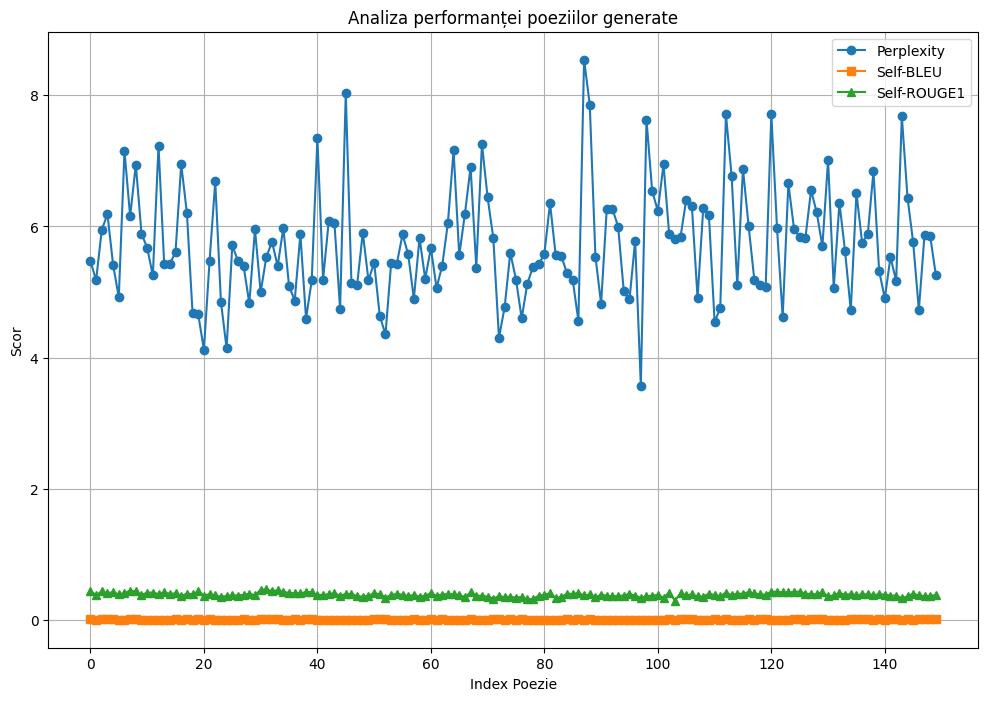

In [ ]:
# Instalăm librăriile necesare
!pip install nltk rouge-score

import torch
import math
import pandas as pd
import matplotlib.pyplot as plt
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from rouge_score import rouge_scorer
from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline
import itertools
import os

# 1. Setăm modelul
MODEL_PATH = "/content/poet_gpt4"  # Modifică dacă e altă locație
tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)
model = AutoModelForCausalLM.from_pretrained(MODEL_PATH)
model.eval()

# 2. Pipeline pentru generare
generator = pipeline(
    "text-generation",
    model=model,
    tokenizer=tokenizer,
)

# 3. Funcții utile
def compute_perplexity(text):
    encodings = tokenizer(text, return_tensors="pt", truncation=True)
    input_ids = encodings.input_ids.to(model.device)

    with torch.no_grad():
        outputs = model(input_ids, labels=input_ids)
        loss = outputs.loss

    perplexity = math.exp(loss.item())
    return perplexity

def genereaza_poezie(autor, titlu, max_cuvinte=100, max_length=300):
    prompt = f"<|autor={autor}|>\n<|titlu={titlu}|>\n<|poezie=>"
    output = generator(
        prompt,
        max_length=max_length,
        num_return_sequences=1,
        do_sample=True,
        temperature=0.7,
        top_k=50,
        top_p=0.9,
        repetition_penalty=1.2,
        early_stopping=True,
    )
    text_generat = output[0]["generated_text"]
    try:
        start = text_generat.index("<|poezie=>") + len("<|poezie=>")
        end = text_generat.index("<|endofpoem|>", start)
        poezie = text_generat[start:end].strip()
    except ValueError:
        poezie = text_generat[start:].strip()
    return poezie

# 4. Definim autorii și titlurile
autori_titluri = {
    "Mihai Eminescu": ["Vis de noapte", "Dor nemărginit", "Adio, destin finit!", "Mama", "Codrul tăcerii"],
    "Lucian Blaga": ["Lumina din paharul de cafea", "Frământare de seară", "Suspin de piatră", "Rugăciune în vânt", "Fântâna mută"],
    "George Bacovia": ["Nori de plumb", "Plânset de toamnă", "Singurătatea ploii", "Amurg de cenușă", "Vise de fum"]
}

# 5. Generăm poeziile
poezii_generate = []
results = []

scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)
smoother = SmoothingFunction().method1

for autor, titluri in autori_titluri.items():
    for titlu in titluri:
        grup_poezii = []

        # Generam 10 poezii pentru fiecare titlu
        for _ in range(10):
            poezie = genereaza_poezie(autor, titlu)
            grup_poezii.append(poezie)
            poezii_generate.append(f"Autor: {autor}\nTitlu: {titlu}\nPoezie:\n{poezie}\n{'-'*50}\n")

        # Calculam scorurile între poeziile generate
        for idx, poezie in enumerate(grup_poezii):
            ppx = compute_perplexity(poezie)

            bleu_scores = []
            rouge1_scores = []
            rougeL_scores = []

            for jdx, alt_poezie in enumerate(grup_poezii):
                if idx != jdx:
                    reference = alt_poezie.split()
                    candidate = poezie.split()
                    bleu = sentence_bleu([reference], candidate, smoothing_function=smoother)
                    rouge = scorer.score(alt_poezie, poezie)

                    bleu_scores.append(bleu)
                    rouge1_scores.append(rouge['rouge1'].fmeasure)
                    rougeL_scores.append(rouge['rougeL'].fmeasure)

            results.append({
                "Autor": autor,
                "Titlu": titlu,
                "Poezie_idx": idx + 1,
                "Perplexity": ppx,
                "Mean_Self_BLEU": sum(bleu_scores) / len(bleu_scores),
                "Mean_Self_ROUGE1": sum(rouge1_scores) / len(rouge1_scores),
                "Mean_Self_ROUGE_L": sum(rougeL_scores) / len(rougeL_scores)
            })

# 6. Salvăm poeziile generate
with open("poezii_generateGPT4_150.txt", "w", encoding="utf-8") as f:
    f.writelines(poezii_generate)

# 7. Salvăm rezultatele într-un CSV
df = pd.DataFrame(results)
df.to_csv("evaluare_poezii_150.csv", index=False)
print("✅ Evaluarea și poeziile au fost salvate!")

# 8. Grafic pentru analiza scorurilor
plt.figure(figsize=(12, 8))
plt.plot(df.index, df["Perplexity"], marker='o', label="Perplexity")
plt.plot(df.index, df["Mean_Self_BLEU"], marker='s', label="Self-BLEU")
plt.plot(df.index, df["Mean_Self_ROUGE1"], marker='^', label="Self-ROUGE1")
plt.title("Analiza performanței poeziilor generate")
plt.xlabel("Index Poezie")
plt.ylabel("Scor")
plt.legend()
plt.grid()
plt.show()




In [ ]:

import pandas as pd

# 1. Încarcă scorurile și poeziile
df = pd.read_csv("evaluare_poezii_150.csv")
with open("poezii_generateGPT4_150.txt", "r", encoding="utf-8") as f:
    poezii = f.read().split("-" * 50 + "\n")

# 2. Creăm un scor compus pentru selecție
df["ScorFinal"] = df["Perplexity"] + (1 - df["Mean_Self_BLEU"]) + (1 - df["Mean_Self_ROUGE1"])

# 3. Selectăm top 5 poezii cu scorul cel mai mic
top5_idx = df.sort_values(by="ScorFinal").head(5).index.tolist()

# 4. Pregătim poeziile în ordinea dorită
poezii_finale = []

# Mai întâi adăugăm Top 5 poezii marcate
for rank, idx in enumerate(top5_idx, 1):
    poezie = poezii[idx].strip()
    poezii_finale.append(f"⭐ Nr.{rank}\n{poezie}\n{'-'*50}\n")

# Apoi adăugăm restul poeziilor (cele care nu sunt în Top 5)
for idx, poezie in enumerate(poezii):
    if idx not in top5_idx and poezie.strip():
        poezii_finale.append(f"{poezie.strip()}\n{'-'*50}\n")

# 5. Salvăm noul document
with open("poezii_generateGPT4_150_top5.txt", "w", encoding="utf-8") as f:
    f.writelines(poezii_finale)

print("✅ Top 5 poezii au fost selectate și salvate primele în noul document 'poezii_generateGPT4_150_top5.txt'.")


✅ Top 5 poezii au fost selectate și salvate primele în noul document 'poezii_generateGPT4_150_top5.txt'.


# INTERMEDIAR - DATE zgomot distributie pt clasificare

           autor        titlu  \
0  Ana Blandiana  Fruntea mea   
1  Ana Blandiana  Am crescut?   
2  Ana Blandiana      Eclipsă   
3  Ana Blandiana   Lună plină   
4  Ana Blandiana      Dorința   

                                                text  
0  Fruntea mea e o piatră\nPeste care trec și se-...  
1  Am crescut? Suntem oameni maturi?\nCâte mii de...  
2  Renunț la milă greu ca la un viciu,\nCu milă s...  
3  Vino, lună, și ne desprinde din somn,\nAruncă-...  
4  Să fie o dimineață copilăroasă și moale\nPrin ...  
Număr total poezii: 917


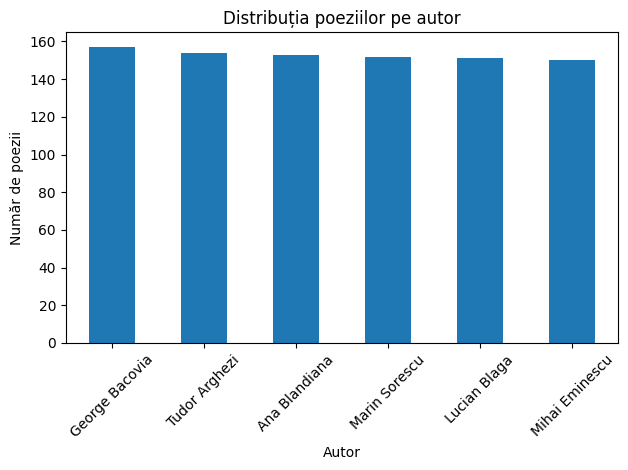

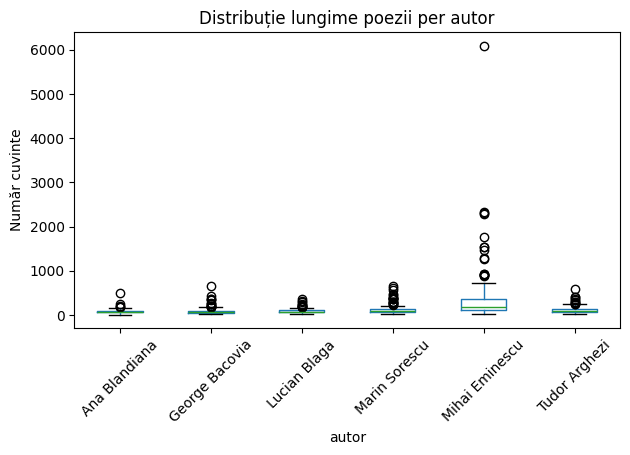

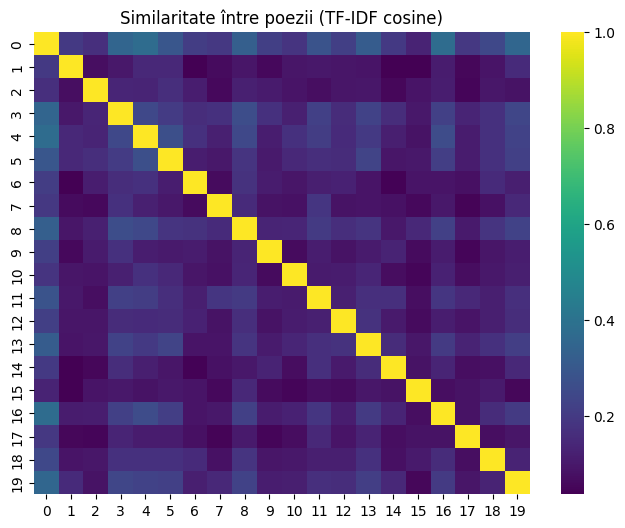

In [ ]:
import pandas as pd

df = pd.read_csv("dataset_generate.csv")
print(df.head())  # vezi structura
print("Număr total poezii:", len(df))

# Distributoe poezii per autor
import matplotlib.pyplot as plt

df["autor"].value_counts().plot(kind="bar", title="Distribuția poeziilor pe autor")
plt.xlabel("Autor")
plt.ylabel("Număr de poezii")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Lungime text per poezie
df["text_len"] = df["text"].apply(lambda x: len(x.split()))
df.boxplot(column="text_len", by="autor", grid=False)
plt.title("Distribuție lungime poezii per autor")
plt.suptitle("")
plt.ylabel("Număr cuvinte")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Similaritate intre poezii random:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import seaborn as sns

sample_texts = df["text"].sample(20, random_state=42)
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(sample_texts)
sim_matrix = cosine_similarity(X)

plt.figure(figsize=(8, 6))
sns.heatmap(sim_matrix, cmap="viridis")
plt.title("Similaritate între poezii (TF-IDF cosine)")
plt.show()



# Part2: I.Date pentru clasificare ! impartire pe strofe

In [ ]:
import pandas as pd

# I: 1.  datasetul original pe STROFE
df = pd.read_csv("dataset_generate.csv")

# 2.  extrage strofele dintr-un text
def split_by_blank_lines(text):
    raw_stanzas = text.strip().split("\n\n")  # separă pe rânduri goale
    stanzas = ["\n".join([line.strip() for line in stanza.split("\n") if line.strip()])
               for stanza in raw_stanzas if stanza.strip()]
    return stanzas

# 3. noul dataset cu strofe
new_rows = []

for _, row in df.iterrows():
    stanzas = split_by_blank_lines(row["text"])
    for idx, stanza in enumerate(stanzas, start=1):
        new_rows.append({
            "autor": row["autor"],
            "titlu": row["titlu"],
            "strofa": idx,
            "text": stanza
        })

# 4. Salvare
df_strofe = pd.DataFrame(new_rows)
df_strofe.to_csv("dataset_strofe.csv", index=False)
print("✅ Noul dataset cu strofe a fost salvat ca 'dataset_strofe.csv'")
print("Număr total de strofe:", len(df_strofe))


✅ Noul dataset cu strofe a fost salvat ca 'dataset_strofe.csv'
Număr total de strofe: 3456


In [ ]:
# II: analiza nr strofe autori/medie versuri etc
import pandas as pd

df = pd.read_csv("dataset_strofe.csv")

df["nr_versuri"] = df["text"].apply(lambda x: len([line for line in x.split("\n") if line.strip()]))

strofe_per_autor = df.groupby("autor").size()
versuri_medii_per_autor = df.groupby("autor")["nr_versuri"].mean()

print("📊 Număr total de strofe per autor:")
print(strofe_per_autor)

print("\n📐 Număr mediu de versuri per strofă per autor:")
print(versuri_medii_per_autor.round(2))

import pandas as pd

df = pd.read_csv("dataset_strofe.csv")

df["nr_versuri"] = df["text"].apply(lambda x: len([line for line in x.split("\n") if line.strip()]))

df_filtered = df[df["nr_versuri"].between(4, 12)]

count_table = df_filtered.groupby(["autor", "nr_versuri"]).size().unstack(fill_value=0).sort_index(axis=1)


print("📊 Număr strofe per autor în funcție de numărul de versuri (4–12):")
print(count_table)


📊 Număr total de strofe per autor:
autor
Ana Blandiana      158
George Bacovia     376
Lucian Blaga       368
Marin Sorescu      562
Mihai Eminescu    1438
Tudor Arghezi      554
dtype: int64

📐 Număr mediu de versuri per strofă per autor:
autor
Ana Blandiana     18.04
George Bacovia     7.18
Lucian Blaga       7.24
Marin Sorescu      6.10
Mihai Eminescu     6.06
Tudor Arghezi      5.78
Name: nr_versuri, dtype: float64
📊 Număr strofe per autor în funcție de numărul de versuri (4–12):
nr_versuri       4    5    6   7    8   9   10  11  12
autor                                                 
Ana Blandiana     0    0    1   0    5   3   4   4  20
George Bacovia  228   22   15   3    6   1   1   0   9
Lucian Blaga     77   49   35  20   22  12  16   9  11
Marin Sorescu   177   76   52  34   27  11   8   5   4
Mihai Eminescu  762  229  102   8  149   1  19   1  16
Tudor Arghezi   265   28   53  14   31   4  11   3   6


**Setul de validare**
- curat, echilibrat, 4-8 versuri per strofa pentru toti autorii
- 203 strofe/autor

In [ ]:
import pandas as pd
from collections import defaultdict
import re

# 1. Incarca fisierul CSV
df = pd.read_csv("dataset_strofe.csv")

# 2. Fct impartire optima in sub-strofe intre 4–12 versuri
def optimal_split(lines, min_len=4, max_len=12):
    total = len(lines)
    best_chunks = []
    best_diff = float('inf')

    for k in range(1, total + 1):
        base = total // k
        if not (min_len <= base <= max_len):
            continue
        chunks = []
        idx = 0
        for i in range(k):
            extra = 1 if i < total % k else 0
            chunk_size = base + extra
            chunks.append(lines[idx:idx + chunk_size])
            idx += chunk_size
        lengths = [len(c) for c in chunks]
        diff = max(lengths) - min(lengths)
        if diff < best_diff:
            best_diff = diff
            best_chunks = chunks

    return best_chunks if best_chunks else [lines]

# 3. Adauga semn de punctuatie daca lipseste
def ensure_punctuation(chunk):
    if not chunk:
        return chunk
    last = chunk[-1].strip()
    if not re.search(r"[.!?…]$", last):
        chunk[-1] = re.sub(r"\W*$", "", chunk[-1]) + "."
    return chunk

# 4. Functia principala de impartire
def split_into_mini_strofe(text, min_len=4, max_len=12):
    lines = [line.strip() for line in text.split("\n") if line.strip()]
    if len(lines) < min_len:
        return []  # doar daca strofa originala e prea mica
    elif min_len <= len(lines) <= max_len:
        return ["\n".join(ensure_punctuation(lines))]
    else:
        chunks = optimal_split(lines, min_len, max_len)
        results = []
        for chunk in chunks:
            chunk = ensure_punctuation(chunk)
            results.append("\n".join(chunk))
        return results

# 5. Aplica transformarea pe dataset
rows = []
strofa_counter = defaultdict(int)
initial_counts = df["autor"].value_counts().to_dict()
final_counts = defaultdict(int)

for _, row in df.iterrows():
    autor = row["autor"]
    titlu = row["titlu"]
    mini_strofe = split_into_mini_strofe(row["text"])

    for ms in mini_strofe:
        strofa_counter[(autor, titlu)] += 1
        final_counts[autor] += 1
        rows.append({
            "autor": autor,
            "titlu": titlu,
            "strofa": strofa_counter[(autor, titlu)],
            "text": ms
        })

# 6. Salvare noul CSV
df_result = pd.DataFrame(rows)
df_result.to_csv("dataset_strofe_normalizat.csv", index=False)
print("✅ Salvat ca dataset_strofe_normalizat.csv")

# 7. Statistici comparative
initial_df = pd.Series(initial_counts, name="initial_strofe")
final_df = pd.Series(final_counts, name="final_strofe")
summary = pd.concat([initial_df, final_df], axis=1)
print("\n📊 Rezumat transformare:")
print(summary)


FileNotFoundError: [Errno 2] No such file or directory: 'dataset_strofe.csv'

In [ ]:
import pandas as pd

# 1. datasetul normalizat
df = pd.read_csv("dataset_strofe_normalizat.csv")

# 2.  500 strofe doar pentru Mihai Eminescu
df_eminescu = df[df["autor"] == "Mihai Eminescu"].head(500)

# 3. pastrare toate strofele pentru restul autorilor
df_rest = df[df["autor"] != "Mihai Eminescu"]

# 4. combina
df_final = pd.concat([df_eminescu, df_rest], ignore_index=True)

# 5. salvare
df_final.to_csv("dataset_clasificare_train.csv", index=False)
print("✅ Salvat: dataset_clasificare_train.csv cu", len(df_final), "strofe.")


✅ Salvat: dataset_clasificare_train.csv cu 2667 strofe.



# **Part2: II. Clasificare**



1.Impartire set de date antrenare test validare

In [ ]:
!pip install spacy scikit-learn
!python -m spacy download ro_core_news_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 22.6 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('ro_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
# CELULA 1 - incarcare, impartire si vectori de stil
import pandas as pd
import spacy
import re
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Dataset
df = pd.read_csv("dataset_clasificare_train.csv")
label_encoder = LabelEncoder()
df["label"] = label_encoder.fit_transform(df["autor"])



df_train, df_temp = train_test_split(df, test_size=0.3, stratify=df["label"], random_state=42)
df_val, df_test = train_test_split(df_temp, test_size=0.5, stratify=df_temp["label"], random_state=42)

# SpaCy model romana
nlp = spacy.load("ro_core_news_sm")

def get_last_syllable(word):
    vowels = "aeiouăîâAEIOUĂÎÂ"
    parts = re.findall(r'[aeiouăîâ]+[^aeiouăîâ\s]*$', word)
    return parts[-1].lower() if parts else word.lower()[-2:]

def detect_rhyme_type(stanza):
    lines = [line.strip() for line in stanza.split("\n") if line.strip()]
    if len(lines) < 2: return 4
    endings = [get_last_syllable(line.split()[-1]) for line in lines]
    def rhymes(a, b): return endings[a] == endings[b]
    if len(lines) >= 4:
        if rhymes(0, 1) and rhymes(2, 3): return 0
        elif rhymes(0, 2) and rhymes(1, 3): return 1
        elif rhymes(0, 3) and rhymes(1, 2): return 2
        elif rhymes(0, 1) and rhymes(1, 2) and rhymes(2, 3): return 3
        elif not any(rhymes(i, j) for i in range(len(endings)) for j in range(i+1, len(endings))): return 4
        elif rhymes(1, 3) and not rhymes(0, 2): return 5
    elif all(end == endings[0] for end in endings): return 3
    return 6

def extract_stylistic_features(text):
    doc = nlp(text)
    num_tokens = len(doc)
    num_verses = text.count("\n") + 1
    avg_verse_len = sum(len(line.strip()) for line in text.split("\n")) / num_verses
    num_adjectives = sum(1 for token in doc if token.pos_ == "ADJ")
    num_verbs = sum(1 for token in doc if token.pos_ == "VERB")
    num_nouns = sum(1 for token in doc if token.pos_ == "NOUN")
    num_punct = sum(1 for token in doc if token.is_punct)
    rhyme_type = detect_rhyme_type(text)
    return [
        num_verses,
        avg_verse_len,
        num_adjectives / num_tokens,
        num_verbs / num_tokens,
        num_nouns / num_tokens,
        num_punct,
        rhyme_type
    ]

for subset in [df_train, df_val, df_test]:
    subset["style_vector"] = subset["text"].apply(extract_stylistic_features)

# Normalizare numerice + adaugare rima
scaler = StandardScaler()
def prepare_style_vectors(df):
    raw = df["style_vector"].tolist()
    numeric = [v[:-1] for v in raw]
    rhyme = [[v[-1]] for v in raw]
    numeric_scaled = scaler.fit_transform(numeric) if df is df_train else scaler.transform(numeric)
    return np.concatenate([numeric_scaled, rhyme], axis=1)

train_styles = prepare_style_vectors(df_train)
val_styles = prepare_style_vectors(df_val)
test_styles = prepare_style_vectors(df_test)

train_texts = list(df_train["text"])
val_texts = list(df_val["text"])
test_texts = list(df_test["text"])

train_labels = list(df_train["label"])
val_labels = list(df_val["label"])
test_labels = list(df_test["label"])

print(df_train.iloc[0]["text"])
print(df_train.iloc[0]["style_vector"])



Sultanul are în palat
Un coș de hârtii pentru capetele domnilor români
Care niciodată nu se nimeresc supuse.
Dar, uite, trunchiul de pe care a fost retezată
Mândria ta de ghiaur
A rămas în picioare,
Ca un stâlp de pridvor românesc înstrăinat
La Istanbul.
[8, 30.875, 0.08928571428571429, 0.03571428571428571, 0.21428571428571427, 5, 6]


2. Tokenizare dataset:
* incarc tokenizerul modelului
* transform train_text si val_text in formatul in care este nevoie

In [ ]:
from transformers import XLMRobertaTokenizer

tokenizer = XLMRobertaTokenizer.from_pretrained("xlm-roberta-base")

train_encodings = tokenizer(list(df_train["text"]), truncation=True, padding=True, return_tensors="pt")
val_encodings = tokenizer(list(df_val["text"]), truncation=True, padding=True, return_tensors="pt")
test_encodings = tokenizer(list(df_test["text"]), truncation=True, padding=True, return_tensors="pt")

train_labels = list(df_train["label"])
val_labels = list(df_val["label"])
test_labels = list(df_test["label"])


3.Creare dataset PyTorch unde combin train_encodings, train_labels și train_styles. Aici creez train_dataset si val_dataset.

Creează un Dataset PyTorch compatibil cu DataLoader
Returnează:
  * input_ids, attention_mask
  * labels (pentru cross-entropy)
  * style_vector (vectorul tău stilistic de 6 dimensiuni)


In [ ]:
import torch

class PoetryDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: val[idx] for key, val in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = PoetryDataset(train_encodings, train_labels)
val_dataset = PoetryDataset(val_encodings, val_labels)
test_dataset = PoetryDataset(test_encodings, test_labels)


In [ ]:
!pip install --upgrade transformers



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 133.0 MB/s eta 0:00:00
  Attempting uninstall: transformers
    Found existing installation: transformers 4.52.2
    Uninstalling transformers-4.52.2:
      Successfully uninstalled transformers-4.52.2


4.Definire model si antrenare si salvare

In [ ]:
from transformers import XLMRobertaForSequenceClassification

num_labels = len(set(train_labels))  # 6 autori

model = XLMRobertaForSequenceClassification.from_pretrained(
    "xlm-roberta-base",
    num_labels=num_labels
)


Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Setup model, dataloader, optimizer și antrenare si setare weight and biases

In [ ]:
!pip install wandb
import wandb
wandb.login()


True

In [ ]:
from transformers import Trainer, TrainingArguments
from sklearn.metrics import classification_report, accuracy_score
import numpy as np

# Functie de metrici
def compute_metrics(pred):
    labels = pred.label_ids
    preds = np.argmax(pred.predictions, axis=1)
    acc = accuracy_score(labels, preds)
    return {"accuracy": acc}

# Argumente antrenare
training_args = TrainingArguments(
    output_dir="./results_xlm",
    num_train_epochs=5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    logging_dir="./logs",
    logging_steps=10,
    do_eval=True,  # activeaza evaluarea
    save_steps=500,
    save_total_limit=2
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
)




In [ ]:
trainer.train()
trainer.evaluate()


Step,Training Loss
10,1.760700
20,1.748800
30,1.799000
40,1.753100
50,1.727400
60,1.662200
70,1.529200
80,1.452300
90,1.299900
100,1.246700


{'eval_loss': 0.6196552515029907,
 'eval_accuracy': 0.7824773413897281,
 'eval_runtime': 8.8206,
 'eval_samples_per_second': 37.526,
 'eval_steps_per_second': 2.381,
 'epoch': 5.0}

5. Testare pe setul de test!

In [ ]:
# Predictii pe setul de test
preds_output = trainer.predict(test_dataset)
y_true = preds_output.label_ids
y_pred = np.argmax(preds_output.predictions, axis=1)

# Raport complet
print(classification_report(y_true, y_pred, target_names=label_encoder.classes_))


                precision    recall  f1-score   support

 Ana Blandiana       0.72      0.78      0.75        55
George Bacovia       0.98      0.89      0.93        55
  Lucian Blaga       0.90      0.98      0.94        56
 Marin Sorescu       0.71      0.75      0.73        55
Mihai Eminescu       0.83      0.79      0.81        56
 Tudor Arghezi       0.76      0.69      0.72        55

      accuracy                           0.81       332
     macro avg       0.82      0.81      0.81       332
  weighted avg       0.82      0.81      0.81       332



6.Evaluare model

                precision    recall  f1-score   support

 Ana Blandiana       1.00      1.00      1.00        31
George Bacovia       1.00      1.00      1.00        32
  Lucian Blaga       1.00      1.00      1.00        30
 Marin Sorescu       1.00      1.00      1.00        30
Mihai Eminescu       1.00      1.00      1.00        30
 Tudor Arghezi       1.00      1.00      1.00        31

      accuracy                           1.00       184
     macro avg       1.00      1.00      1.00       184
  weighted avg       1.00      1.00      1.00       184



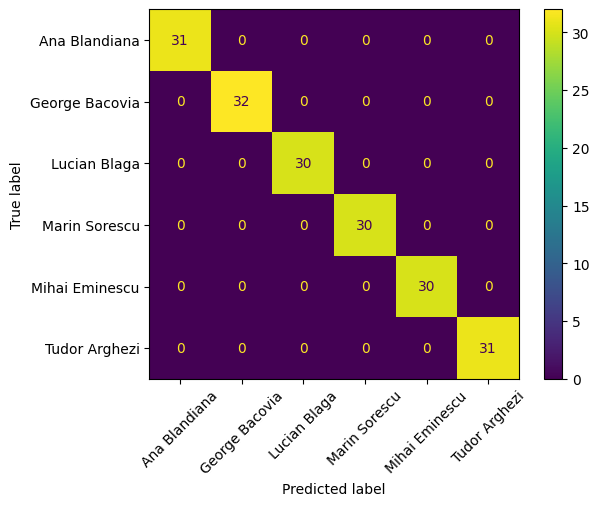

In [ ]:
accuracy = (preds == labels).sum() / len(labels)

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
disp.plot(xticks_rotation=45)
from sklearn.metrics import classification_report
print(classification_report(all_labels, all_preds, target_names=label_encoder.classes_))


6.Intelegere tokeni si model

In [ ]:
from transformers import XLMRobertaTokenizer

tokenizer = XLMRobertaTokenizer.from_pretrained("xlm-roberta-base")

text = "Luceafărul coboară încet în mare."
tokens = tokenizer.tokenize(text)
ids = tokenizer.convert_tokens_to_ids(tokens)

for t, i in zip(tokens, ids):
    print(f"{t:15} -> {i}")
example = train_dataset[0]
print("Input IDs:", example["input_ids"][:20])  # primii 20 de tokeni
print("Label:", example["labels"])


▁Lu             -> 3350
cea             -> 45710
fă              -> 81393
rul             -> 13500
▁co             -> 552
bo              -> 837
ară             -> 21511
▁încet          -> 160318
▁în             -> 346
▁mare           -> 3749
.               -> 5
Input IDs: tensor([     0,   5655,  81267,  17566,   8554, 166369,     31,   1573, 132393,
           202,   7822,    314, 214600,  52521,     91,      9,    916,  27424,
         76329,  29464])
Label: tensor(5)


In [ ]:

model.save_pretrained("xlmr_poet_final")
tokenizer.save_pretrained("xlmr_poet_final")

from google.colab import drive
drive.mount('/content/drive')

!cp -r xlmr_poet_final /content/drive/MyDrive/



Mounted at /content/drive
